# Cross-checking the ±60° WAC_EMP seam with ASP `dem_mosaic`

`wac_emp_seam_investigation.ipynb` found a real, few-percent radiometric step between WAC_EMP's
equirectangular and polar-stereographic tile products at their shared ±60° boundary, already
present in each tile's own native pixels -- not something this project's own reprojection/merge
code (`ortho_wac_emp.reproject_wac_emp_reflectance_to_local_grid`,
`geo_utils.merge_local_grid_arrays`) introduces. This notebook cross-checks that conclusion with an
independent tool: ASP's `dem_mosaic`, mosaicking the same two tiles (each already reprojected onto
the same destination grid `ortho_wac_emp.tif` uses) instead of our own merge step.

`dem_mosaic --first` keeps the first-listed input's value wherever it has one, with no blending
(`--priority-blending-length` defaults to 0) -- the equirect tile is listed first so it takes
precedence wherever the two overlap, per the user's request. `dem_mosaic --count` (a separate run --
these are mutually exclusive aggregation modes) reports, per pixel, how many of the two inputs
actually had data there -- 0 means neither tile covers it (a gap), 2 means both do (an overlap) --
which answers the coverage question directly at the same resolution the mosaic is actually built at,
rather than inferring it from each tile's own native-latitude range the way the previous notebook did.

In [1]:
import math

import matplotlib.pyplot as plt
import numpy as np
import rasterio
from rasterio.transform import from_bounds as transform_from_bounds
from rasterio.warp import Resampling, transform_bounds
from rasterio.windows import from_bounds as window_from_bounds
from rasterio.windows import transform as window_transform
from scipy import ndimage

import trntest
from trntest import cache
from trntest.config import MOON_RADIUS_M
from trntest.geo_utils import local_orthographic_crs
from trntest.ortho_wac_emp import _reproject_one_wac_emp_tile_to_array, wac_emp_tile_ids_for_bbox
from trntest.subprocess_utils import run_quiet

config = trntest.load_config()
dataset = trntest.TrnTestDataSet.open(config.output_dir / "trntest1", config)

BAD_ENTRIES = ["M1314469291CE", "M1314314993CE"]  # trntest1 indices 201 and 3
CROP_SIZE = 200  # same crop size wac_emp_seam_investigation.ipynb used
SCRATCH_DIR = config.scratch_dir / "wac_emp_seam_dem_mosaic"
SCRATCH_DIR.mkdir(parents=True, exist_ok=True)

## Reproject each source tile independently, onto the same grid `ortho_wac_emp.tif` used

Reusing `ortho_wac_emp._reproject_one_wac_emp_tile_to_array` (the single-tile core the production
path already calls once per tile) keeps this a fair test of the *merge* step specifically, not a
second, independently-written reprojection that could introduce its own differences. Each tile's
reprojected array is written to its own GeoTIFF with a real `nodata` tag (`NaN`) -- the production
path never writes these intermediates to disk, keeping them as in-memory arrays for
`merge_local_grid_arrays` instead -- so `dem_mosaic` (a separate process, reading real files) has
something to read.

In [2]:
entries = {}
for product_id in BAD_ENTRIES:
    entry = dataset[product_id]
    with rasterio.open(entry.per_image_config.output_dir / "ortho_wac_emp.tif") as src:
        dst_bbox_m = src.bounds
        dst_width, dst_height = src.width, src.height
        original_array = src.read(1)
        # The manifest's own `center_lon_deg`/`center_lat_deg` columns are an earlier, approximate
        # cataloging-time estimate -- not necessarily identical to the camera's actual footprint
        # center `dem_ortho.fetch_and_shade_ortho` used as this file's own local-Orthographic tangent
        # point. Reading it back out of the file's own CRS instead reproduces the exact same
        # destination grid `ortho_wac_emp.tif` was generated on.
        center_lon_deg, center_lat_deg = src.crs.to_dict()["lon_0"], src.crs.to_dict()["lat_0"]

    tile_ids = sorted(
        wac_emp_tile_ids_for_bbox(dst_bbox_m, center_lon_deg, center_lat_deg, MOON_RADIUS_M),
        key=lambda t: "P900" in t,  # equirect first, polar second
    )
    entry_dir = SCRATCH_DIR / product_id
    entry_dir.mkdir(exist_ok=True)
    dst_crs = local_orthographic_crs(center_lon_deg, center_lat_deg, MOON_RADIUS_M)
    dst_transform = transform_from_bounds(*dst_bbox_m, dst_width, dst_height)
    profile = {
        "driver": "GTiff",
        "height": dst_height,
        "width": dst_width,
        "count": 1,
        "dtype": "float32",
        "crs": dst_crs,
        "transform": dst_transform,
        "nodata": float("nan"),
    }
    tile_paths = []
    for tile_id in tile_ids:
        cached_tile_path = cache.fetch_wac_emp_tile(tile_id, config.cache_root, config.wac_emp_base_url)
        reprojected = _reproject_one_wac_emp_tile_to_array(
            cached_tile_path,
            dst_bbox_m,
            dst_width,
            dst_height,
            center_lon_deg,
            center_lat_deg,
            MOON_RADIUS_M,
            Resampling.bilinear,
            0.125,
        )
        tile_path = entry_dir / f"{tile_id}.tif"
        with rasterio.open(tile_path, "w", **profile) as dst:
            dst.write(reprojected, 1)
        tile_paths.append(tile_path)

    entries[product_id] = {
        "tile_ids": tile_ids,
        "tile_paths": tile_paths,
        "original_array": original_array,
        "dst_bbox_m": dst_bbox_m,
        "dst_width": dst_width,
        "dst_height": dst_height,
        "center_lon_deg": center_lon_deg,
        "center_lat_deg": center_lat_deg,
    }
    print(f"{product_id}: {tile_ids} -> {[str(p) for p in tile_paths]}")

M1314469291CE: ['WAC_EMP_643NM_E300S1350_304P', 'WAC_EMP_643NM_P900S0000_304P'] -> ['/workspace/scratch/wac_emp_seam_dem_mosaic/M1314469291CE/WAC_EMP_643NM_E300S1350_304P.tif', '/workspace/scratch/wac_emp_seam_dem_mosaic/M1314469291CE/WAC_EMP_643NM_P900S0000_304P.tif']


M1314314993CE: ['WAC_EMP_643NM_E300S1350_304P', 'WAC_EMP_643NM_P900S0000_304P'] -> ['/workspace/scratch/wac_emp_seam_dem_mosaic/M1314314993CE/WAC_EMP_643NM_E300S1350_304P.tif', '/workspace/scratch/wac_emp_seam_dem_mosaic/M1314314993CE/WAC_EMP_643NM_P900S0000_304P.tif']


## Mosaic with `dem_mosaic --first` (no blending) and `dem_mosaic --count`

In [3]:
# `dem_mosaic` ignores each input's own NaN nodata tag and writes its own standard sentinel
# (~-3.4e38) as the OUTPUT nodata value regardless -- including for `--count`, where "zero valid
# inputs at this pixel" comes out as that same sentinel rather than a literal `0` (there's no count
# to report, so it's nodata too). Both are converted back to an explicit, arithmetic-safe convention
# below: `NaN` for `--first`, literal `0` for `--count`.
for product_id, e in entries.items():
    first_path = SCRATCH_DIR / product_id / "mosaic_first.tif"
    count_path = SCRATCH_DIR / product_id / "mosaic_count.tif"
    run_quiet(["dem_mosaic", "--first", *(str(p) for p in e["tile_paths"]), "-o", str(first_path)])
    run_quiet(["dem_mosaic", "--count", *(str(p) for p in e["tile_paths"]), "-o", str(count_path)])
    with rasterio.open(first_path) as src:
        arr, nodata = src.read(1), src.nodata
        e["dem_mosaic_array"] = np.where(arr == nodata, np.nan, arr) if nodata is not None else arr
    with rasterio.open(count_path) as src:
        arr, nodata = src.read(1), src.nodata
        e["count_array"] = np.where(arr == nodata, 0, arr) if nodata is not None else arr
    print(f"{product_id}: dem_mosaic done")

M1314469291CE: dem_mosaic done


M1314314993CE: dem_mosaic done


## Does `dem_mosaic --first` reproduce the same seam, at the same row?

If ASP's own mosaicking tool draws the boundary at a different row, or produces a smoother
transition, that would point at something specific to this project's own merge code rather than a
property of the source data.

In [4]:
for product_id, e in entries.items():
    original, dem_mosaic_out = e["original_array"], e["dem_mosaic_array"]
    diff = dem_mosaic_out - original
    original_seam_row = int(np.argmax(np.abs(np.diff(np.nanmean(original, axis=1)))))
    dem_mosaic_seam_row = int(np.argmax(np.abs(np.diff(np.nanmean(dem_mosaic_out, axis=1)))))
    print(
        f"{product_id}: our own merge's largest jump at row {original_seam_row}, "
        f"dem_mosaic's at row {dem_mosaic_seam_row}; max|dem_mosaic - original| = {np.nanmax(np.abs(diff)):.4f}"
    )

M1314469291CE: our own merge's largest jump at row 555, dem_mosaic's at row 555; max|dem_mosaic - original| = 0.0480
M1314314993CE: our own merge's largest jump at row 570, dem_mosaic's at row 570; max|dem_mosaic - original| = 0.0845


## Zoom: the same 200×200 crop, from `dem_mosaic --first`'s output

Same crop location `wac_emp_seam_investigation.ipynb` used (centered on that notebook's own
`seam_row`/image-center column), stacked vertically rather than side by side so each crop keeps its
full resolution.

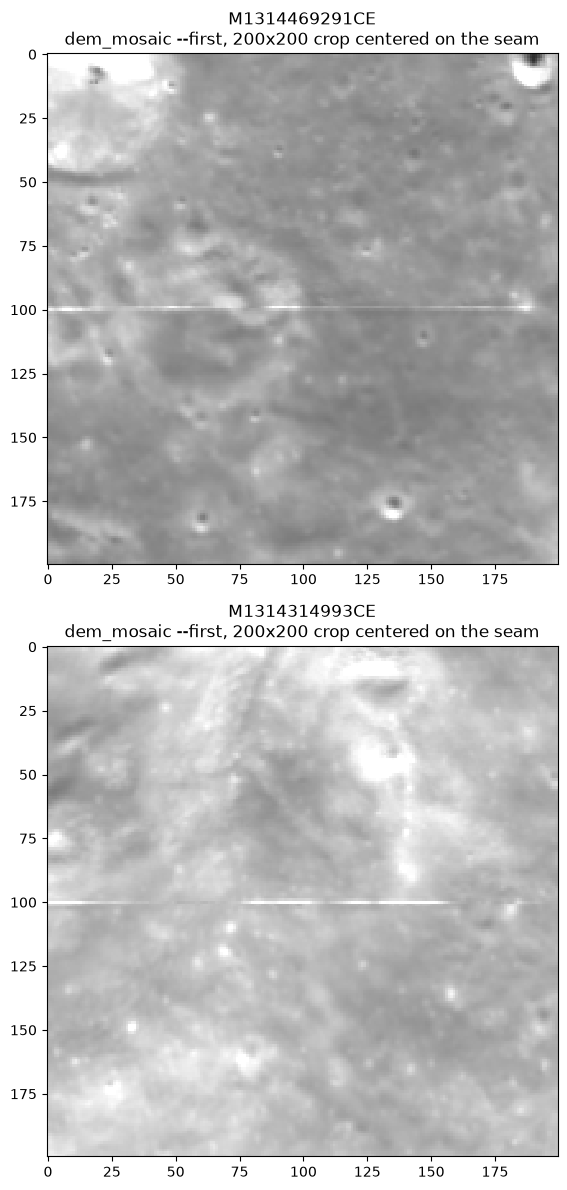

In [5]:
seam_rows = {}
for product_id, e in entries.items():
    row_means = np.nanmean(e["dem_mosaic_array"], axis=1)
    seam_rows[product_id] = int(np.argmax(np.abs(np.diff(row_means))))

fig, axes = plt.subplots(len(entries), 1, figsize=(6, 6 * len(entries)))
for ax, (product_id, e) in zip(axes, entries.items(), strict=True):
    arr = e["dem_mosaic_array"]
    height, width = arr.shape
    row0 = seam_rows[product_id] - CROP_SIZE // 2
    col0 = width // 2 - CROP_SIZE // 2
    crop = arr[row0 : row0 + CROP_SIZE, col0 : col0 + CROP_SIZE]
    vmax = np.nanpercentile(crop, 99)
    ax.imshow(crop, cmap="gray", vmin=0, vmax=vmax, interpolation="nearest")
    ax.set_title(f"{product_id}\ndem_mosaic --first, {CROP_SIZE}x{CROP_SIZE} crop centered on the seam")
plt.tight_layout()

## The same crop, in `--count` values

1 = only one tile covers this pixel (the expected value almost everywhere); 0 = neither tile does
(a real gap); 2 = both do (a real overlap `--first` had to arbitrate).

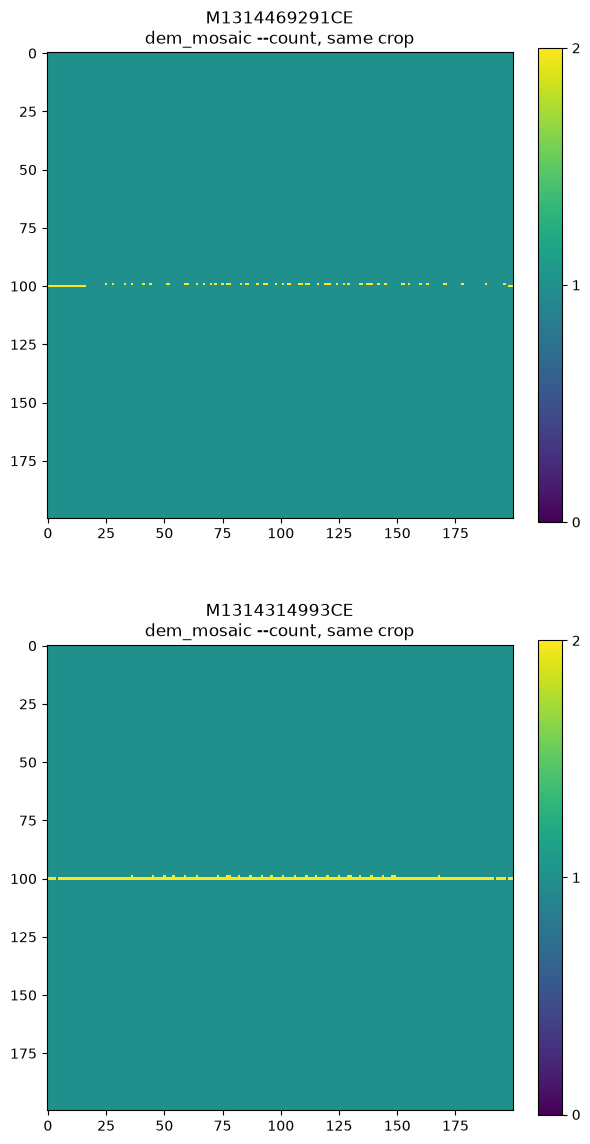

In [6]:
fig, axes = plt.subplots(len(entries), 1, figsize=(6, 6 * len(entries)))
for ax, (product_id, e) in zip(axes, entries.items(), strict=True):
    arr = e["count_array"]
    height, width = arr.shape
    row0 = seam_rows[product_id] - CROP_SIZE // 2
    col0 = width // 2 - CROP_SIZE // 2
    crop = arr[row0 : row0 + CROP_SIZE, col0 : col0 + CROP_SIZE]
    im = ax.imshow(crop, cmap="viridis", vmin=0, vmax=2, interpolation="nearest")
    ax.set_title(f"{product_id}\ndem_mosaic --count, same crop")
    plt.colorbar(im, ax=ax, ticks=[0, 1, 2], fraction=0.046)
plt.tight_layout()

## Count value histogram (whole image, not just the crop)

In [7]:
for product_id, e in entries.items():
    values, counts = np.unique(e["count_array"], return_counts=True)
    total = e["count_array"].size
    breakdown = ", ".join(f"{int(v)}: {c} ({100 * c / total:.4f}%)" for v, c in zip(values, counts, strict=True))
    print(f"{product_id}: {breakdown}")

M1314469291CE: 0: 9 (0.0004%), 1: 2100770 (99.9605%), 2: 821 (0.0391%)
M1314314993CE: 0: 9 (0.0005%), 1: 1971742 (99.9240%), 2: 1490 (0.0755%)


`0` (gap) and `2` (overlap) both turn out to be real, not rounding noise -- but they aren't at the
same place. Where do they actually fall?

In [8]:
N_TILES = 2  # equirect + polar -- a pixel both cover has count == N_TILES

for product_id, e in entries.items():
    count = e["count_array"]
    gap_rows = np.where(count == 0)[0]
    overlap_rows = np.where(count == N_TILES)[0]
    print(
        f"{product_id}: gap rows span [{gap_rows.min()}, {gap_rows.max()}] ({len(gap_rows)} px); "
        f"overlap rows span [{overlap_rows.min()}, {overlap_rows.max()}] ({len(overlap_rows)} px); "
        f"seam row = {seam_rows[product_id]}"
    )

M1314469291CE: gap rows span [79, 377] (9 px); overlap rows span [554, 582] (821 px); seam row = 555
M1314314993CE: gap rows span [400, 933] (9 px); overlap rows span [569, 596] (1490 px); seam row = 570


## Does giving the polar tile precedence instead change anything?

So far the equirect tile has always won the overlap band. If the step were actually an edge
artifact specific to *one* tile -- say, a resampling/extrapolation glitch in the equirect tile's own
southernmost rows -- giving the other tile precedence there should visibly soften, shift, or remove
it. Flipping `dem_mosaic --first`'s input order tests that directly: everything else (each tile's
own reprojected pixel values) is unchanged, only which one wins inside the overlap band flips.

In [9]:
for product_id, e in entries.items():
    polar_first_path = SCRATCH_DIR / product_id / "mosaic_first_polar_precedence.tif"
    run_quiet(["dem_mosaic", "--first", *(str(p) for p in reversed(e["tile_paths"])), "-o", str(polar_first_path)])
    with rasterio.open(polar_first_path) as src:
        arr, nodata = src.read(1), src.nodata
        e["dem_mosaic_array_polar_precedence"] = np.where(arr == nodata, np.nan, arr) if nodata is not None else arr
    print(f"{product_id}: dem_mosaic (polar precedence) done")

M1314469291CE: dem_mosaic (polar precedence) done


M1314314993CE: dem_mosaic (polar precedence) done


In [10]:
FLOAT32_NOISE_FLOOR = 1e-6  # below this, a diff is round-trip-through-float32 noise, not a real change

for product_id, e in entries.items():
    equirect_first, polar_first = e["dem_mosaic_array"], e["dem_mosaic_array_polar_precedence"]
    changed = np.abs(polar_first - equirect_first) > FLOAT32_NOISE_FLOOR
    changed_rows = np.where(changed.any(axis=1))[0]
    seam_row_polar_first = int(np.argmax(np.abs(np.diff(np.nanmean(polar_first, axis=1)))))
    print(
        f"{product_id}: {changed.sum()} pixels changed ({100 * changed.sum() / changed.size:.4f}%), "
        f"changed rows span [{changed_rows.min()}, {changed_rows.max()}]; "
        f"seam row with polar precedence = {seam_row_polar_first} "
        f"(equirect precedence: {seam_rows[product_id]})"
    )

M1314469291CE: 821 pixels changed (0.0391%), changed rows span [554, 582]; seam row with polar precedence = 555 (equirect precedence: 555)
M1314314993CE: 1489 pixels changed (0.0755%), changed rows span [569, 596]; seam row with polar precedence = 570 (equirect precedence: 570)


### The same 200×200 crop, with polar precedence

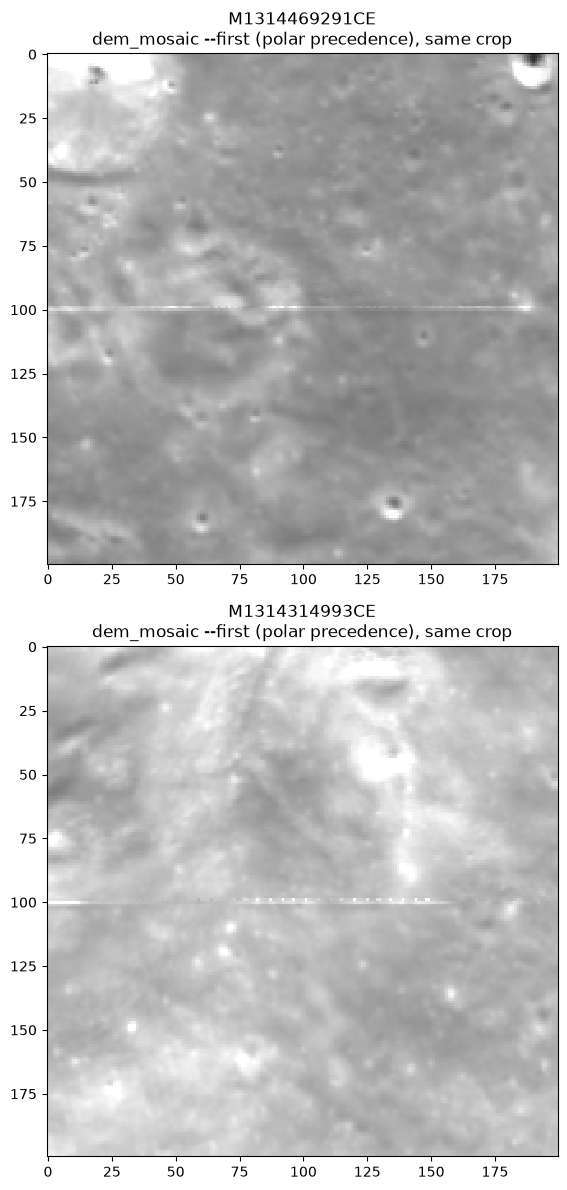

In [11]:
fig, axes = plt.subplots(len(entries), 1, figsize=(6, 6 * len(entries)))
for ax, (product_id, e) in zip(axes, entries.items(), strict=True):
    arr = e["dem_mosaic_array_polar_precedence"]
    height, width = arr.shape
    row0 = seam_rows[product_id] - CROP_SIZE // 2
    col0 = width // 2 - CROP_SIZE // 2
    crop = arr[row0 : row0 + CROP_SIZE, col0 : col0 + CROP_SIZE]
    vmax = np.nanpercentile(crop, 99)
    ax.imshow(crop, cmap="gray", vmin=0, vmax=vmax, interpolation="nearest")
    ax.set_title(f"{product_id}\ndem_mosaic --first (polar precedence), same crop")
plt.tight_layout()

## What's actually happening at the seam row, pixel by pixel?

The crop comparison above is too coarse to show why the two precedence orders can look different at
all, given `--count` says almost the whole row is single-coverage. Reading each tile's own
reprojected value directly at the seam row -- not the merged result -- for a stretch of columns.

In [12]:
def _n_valid_runs(is_valid: np.ndarray) -> int:
    """How many separate contiguous runs of `True` `is_valid` has -- 1 for one clean, unbroken edge
    crossing; many for a jagged edge that crosses back and forth."""
    padded = np.concatenate(([False], is_valid, [False]))
    return int(np.sum(np.diff(padded.astype(int)) == 1))


for product_id, e in entries.items():
    row = seam_rows[product_id]
    equirect_path, polar_path = e["tile_paths"]  # equirect-first order from the reprojection step
    with rasterio.open(equirect_path) as src:
        equirect_row = src.read(1, window=((row, row + 1), (0, e["dst_width"])))[0]
    with rasterio.open(polar_path) as src:
        polar_row = src.read(1, window=((row, row + 1), (0, e["dst_width"])))[0]
    both_valid = ~np.isnan(equirect_row) & ~np.isnan(polar_row)
    n_runs = _n_valid_runs(~np.isnan(polar_row))
    print(f"{product_id}: seam row {row}")
    print(
        f"  where both are valid, equirect ranges [{equirect_row[both_valid].min():.4f}, "
        f"{equirect_row[both_valid].max():.4f}], polar ranges [{polar_row[both_valid].min():.4f}, "
        f"{polar_row[both_valid].max():.4f}]"
    )
    print(f"  polar is valid at this row in {n_runs} separate runs of columns (a clean single edge would give 1)")

M1314469291CE: seam row 555
  where both are valid, equirect ranges [0.0921, 0.2354], polar ranges [0.0959, 0.1921]
  polar is valid at this row in 28 separate runs of columns (a clean single edge would give 1)
M1314314993CE: seam row 570
  where both are valid, equirect ranges [0.0900, 0.2050], polar ranges [0.0810, 0.1676]
  polar is valid at this row in 22 separate runs of columns (a clean single edge would give 1)


The polar tile is valid at the seam row in many short, separated runs of columns, not one
contiguous block -- exactly what a locally-diagonal coverage edge crossing a single destination row
back and forth looks like once rasterized onto a rectangular grid. Wherever polar happens to have
data, its own value there can differ noticeably from equirect's value at that same pixel (both
directions -- sometimes brighter, sometimes dimmer) -- so giving polar precedence swaps in a
scattered, non-contiguous set of differing pixels along the row: visually, a periodic-looking
pattern breaking up what is otherwise a smooth (if anomalously bright, per
`wac_emp_seam_investigation.ipynb`) equirect gradient. Equirect precedence never shows this, since
equirect has real data at literally every column of this row -- there's no gap for polar's own
scattered values to show through.

## Would masking the equirect tile's own known-bad edge row(s) fix it?

One candidate explanation for the edge row's own brightness: improper nodata handling wherever
USGS/ASU produced this tile (e.g. an edge-of-data averaging step that let some invalid/background
value leak into the boundary row). If so, masking that row out before mosaicking -- treating it as
nodata rather than real data -- should remove the bright band. The two tiles' own coverage already
meets within one native pixel of an exact edge (`wac_emp_seam_investigation.ipynb`), so masking rows
away from the equirect side alone, with nothing added back from the polar side, risks opening a real
gap instead of just trimming a redundant overlap -- worth checking directly rather than assuming
either way.

This only masks the equirect tile. `wac_emp_seam_investigation.ipynb` also finds a real (smaller,
~5%) edge-brightening effect on the polar side once measured properly (a radial profile around its
own boundary circle, not the coarse per-longitude probe tried first) -- not addressed here.

In [13]:
def _make_masked_equirect_copy(
    tile_path, dst_bbox_m, center_lon_deg, center_lat_deg, moon_radius_m, n_rows_to_mask, out_path
):
    """Writes a small, still-correctly-georeferenced GeoTIFF covering the same AOI window
    `_reproject_one_wac_emp_tile_to_array` would read from `tile_path`, with the tile's own last
    `n_rows_to_mask` native rows (nearest its own ±60° edge) set to NaN -- so
    `_reproject_one_wac_emp_tile_to_array` can be called on this file unmodified, in place of the
    original tile, without needing its own masking parameter."""
    with rasterio.open(tile_path) as src:
        tile_height = src.height
        left, bottom, right, top = transform_bounds(
            local_orthographic_crs(center_lon_deg, center_lat_deg, moon_radius_m), src.crs, *dst_bbox_m
        )
        circumference_m = 2 * math.pi * moon_radius_m
        if right < src.bounds.left:
            left, right = left + circumference_m, right + circumference_m
        elif left > src.bounds.right:
            left, right = left - circumference_m, right - circumference_m
        # Rounded to a whole-pixel window up front (rather than relying on `read`'s own internal
        # rounding) so `window.row_off` reliably identifies which absolute tile rows ended up in
        # `arr` -- needed to mask exactly the tile's own last `n_rows_to_mask` rows, not an
        # approximation of them.
        window = window_from_bounds(left, bottom, right, top, transform=src.transform).round_offsets().round_lengths()
        # The equirect tile turns out to carry a real embedded `nodata` value after all (contrary to
        # `docs/data-sources/wac-emp-pds4.md`'s note, which was based on smaller AOIs than this
        # notebook's full-image window) -- read with `boundless=True` alone would let those real
        # sentinel-valued pixels straight through unconverted, since it only fills gaps *outside* the
        # tile's own raster extent, not real values *within* it.
        src_nodata = src.nodata
        arr = src.read(1, window=window, boundless=True, fill_value=src_nodata if src_nodata is not None else np.nan)
        if src_nodata is not None:
            arr = np.where(arr == src_nodata, np.nan, arr)
        window_row_off = int(window.row_off)
        rows_in_window = np.arange(arr.shape[0]) + window_row_off >= tile_height - n_rows_to_mask
        arr[rows_in_window, :] = np.nan
        profile = {
            "driver": "GTiff",
            "height": arr.shape[0],
            "width": arr.shape[1],
            "count": 1,
            "dtype": "float32",
            "crs": src.crs,
            "transform": window_transform(window, src.transform),
            "nodata": float("nan"),
        }
        with rasterio.open(out_path, "w", **profile) as dst:
            dst.write(arr, 1)
    return out_path


MASK_N_ROWS = (1, 2, 3)
masked_results = {n_rows: {} for n_rows in MASK_N_ROWS}

for n_rows in MASK_N_ROWS:
    print(f"--- masking equirect's last {n_rows} native row(s) ---")
    for product_id, e in entries.items():
        equirect_tile_id = e["tile_ids"][0]
        cached_equirect_path = cache.fetch_wac_emp_tile(equirect_tile_id, config.cache_root, config.wac_emp_base_url)
        masked_path = SCRATCH_DIR / product_id / f"equirect_masked_{n_rows}.tif"
        _make_masked_equirect_copy(
            cached_equirect_path,
            e["dst_bbox_m"],
            e["center_lon_deg"],
            e["center_lat_deg"],
            MOON_RADIUS_M,
            n_rows,
            masked_path,
        )
        reprojected = _reproject_one_wac_emp_tile_to_array(
            masked_path,
            e["dst_bbox_m"],
            e["dst_width"],
            e["dst_height"],
            e["center_lon_deg"],
            e["center_lat_deg"],
            MOON_RADIUS_M,
            Resampling.bilinear,
            0.125,
        )
        reprojected_path = SCRATCH_DIR / product_id / f"equirect_masked_{n_rows}_reprojected.tif"
        with rasterio.open(e["tile_paths"][0]) as ref:
            profile = ref.profile
        with rasterio.open(reprojected_path, "w", **profile) as dst:
            dst.write(reprojected, 1)

        first_path = SCRATCH_DIR / product_id / f"mosaic_first_masked_{n_rows}.tif"
        count_path = SCRATCH_DIR / product_id / f"mosaic_count_masked_{n_rows}.tif"
        run_quiet(["dem_mosaic", "--first", str(reprojected_path), str(e["tile_paths"][1]), "-o", str(first_path)])
        run_quiet(["dem_mosaic", "--count", str(reprojected_path), str(e["tile_paths"][1]), "-o", str(count_path)])
        with rasterio.open(first_path) as src:
            arr, nodata = src.read(1), src.nodata
            merged = np.where(arr == nodata, np.nan, arr) if nodata is not None else arr
        with rasterio.open(count_path) as src:
            arr, nodata = src.read(1), src.nodata
            count = np.where(arr == nodata, 0, arr) if nodata is not None else arr

        row_means = np.nanmean(merged, axis=1)
        new_seam_row = int(np.argmax(np.abs(np.diff(row_means))))
        gap_rows = np.where(count == 0)[0]
        print(
            f"  {product_id}: seam row {new_seam_row} jump = {np.max(np.abs(np.diff(row_means))):.4f} "
            f"(original unmasked jump was {np.max(np.abs(np.diff(np.nanmean(e['dem_mosaic_array'], axis=1)))):.4f}); "
            f"{len(gap_rows)} 0-count (gap) pixels, rows [{gap_rows.min()}, {gap_rows.max()}] "
            f"(baseline was 9 pixels, unrelated to the seam)"
        )
        masked_results[n_rows][product_id] = {"merged": merged, "count": count}

--- masking equirect's last 1 native row(s) ---


  M1314469291CE: seam row 555 jump = 0.0020 (original unmasked jump was 0.0037); 671 0-count (gap) pixels, rows [79, 582] (baseline was 9 pixels, unrelated to the seam)


  M1314314993CE: seam row 570 jump = 0.0023 (original unmasked jump was 0.0036); 141 0-count (gap) pixels, rows [400, 933] (baseline was 9 pixels, unrelated to the seam)
--- masking equirect's last 2 native row(s) ---


  M1314469291CE: seam row 554 jump = 0.0030 (original unmasked jump was 0.0037); 2144 0-count (gap) pixels, rows [79, 582] (baseline was 9 pixels, unrelated to the seam)


  M1314314993CE: seam row 570 jump = 0.0025 (original unmasked jump was 0.0036); 1381 0-count (gap) pixels, rows [400, 933] (baseline was 9 pixels, unrelated to the seam)
--- masking equirect's last 3 native row(s) ---


  M1314469291CE: seam row 554 jump = 0.0035 (original unmasked jump was 0.0037); 3622 0-count (gap) pixels, rows [79, 582] (baseline was 9 pixels, unrelated to the seam)


  M1314314993CE: seam row 570 jump = 0.0026 (original unmasked jump was 0.0036); 2813 0-count (gap) pixels, rows [400, 933] (baseline was 9 pixels, unrelated to the seam)


### The same 200×200 crop, for each masked mosaic and its `--count` map

Same crop location as every earlier crop in this notebook (centered on `seam_rows[product_id]`).
`--count` values are shown on the same 0-2 scale as the unmasked version above -- a dark patch where
there used to be none is the new gap; the fact that `--count`'s own gap encoding is ASP's own nodata
sentinel rather than a literal `0` (noted above `dem_mosaic` runs earlier in this notebook) is
already converted back before display, same as everywhere else here.

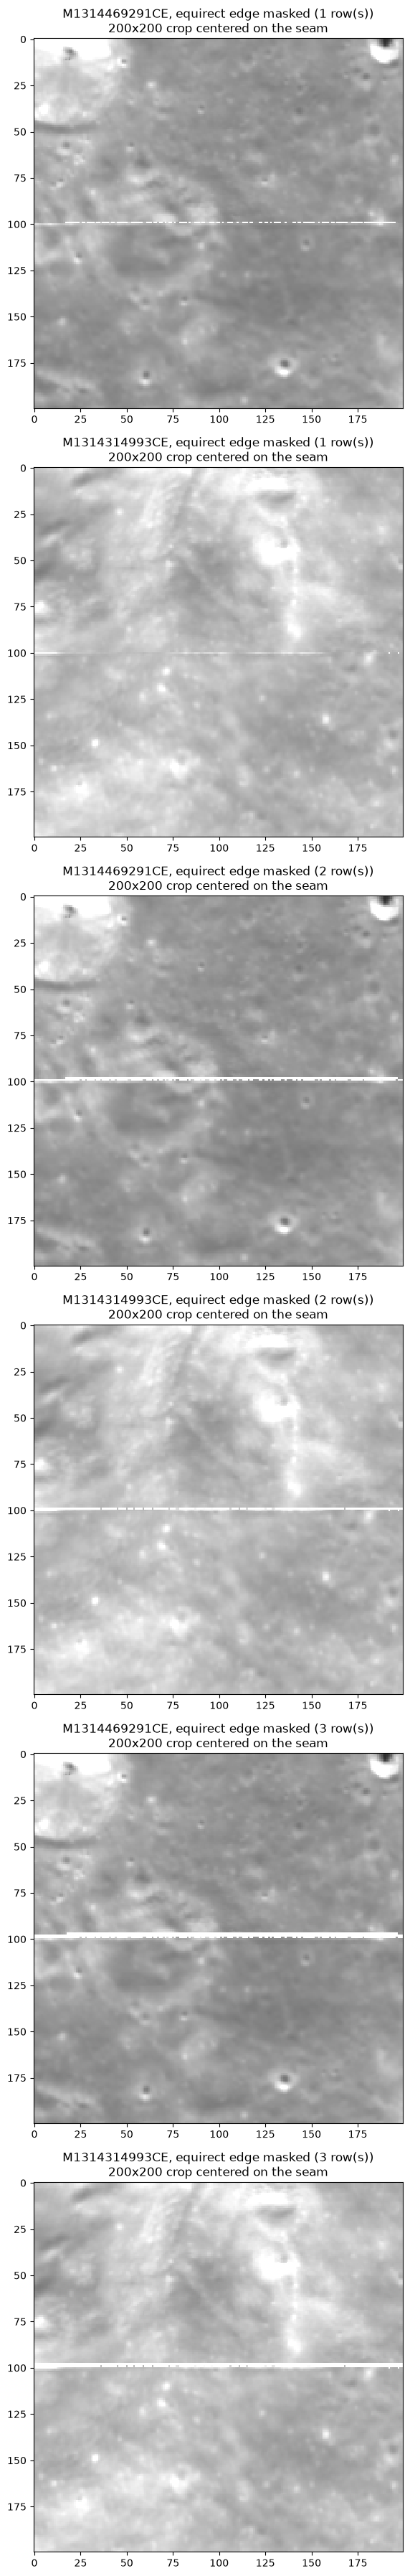

In [14]:
fig, axes = plt.subplots(len(MASK_N_ROWS) * len(entries), 1, figsize=(6, 6 * len(MASK_N_ROWS) * len(entries)))
ax_iter = iter(axes)
for n_rows in MASK_N_ROWS:
    for product_id, result in masked_results[n_rows].items():
        arr = result["merged"]
        row0 = seam_rows[product_id] - CROP_SIZE // 2
        col0 = arr.shape[1] // 2 - CROP_SIZE // 2
        crop = arr[row0 : row0 + CROP_SIZE, col0 : col0 + CROP_SIZE]
        vmax = np.nanpercentile(crop, 99)
        ax = next(ax_iter)
        ax.imshow(crop, cmap="gray", vmin=0, vmax=vmax, interpolation="nearest")
        ax.set_title(
            f"{product_id}, equirect edge masked ({n_rows} row(s))\n{CROP_SIZE}x{CROP_SIZE} crop centered on the seam"
        )
plt.tight_layout()

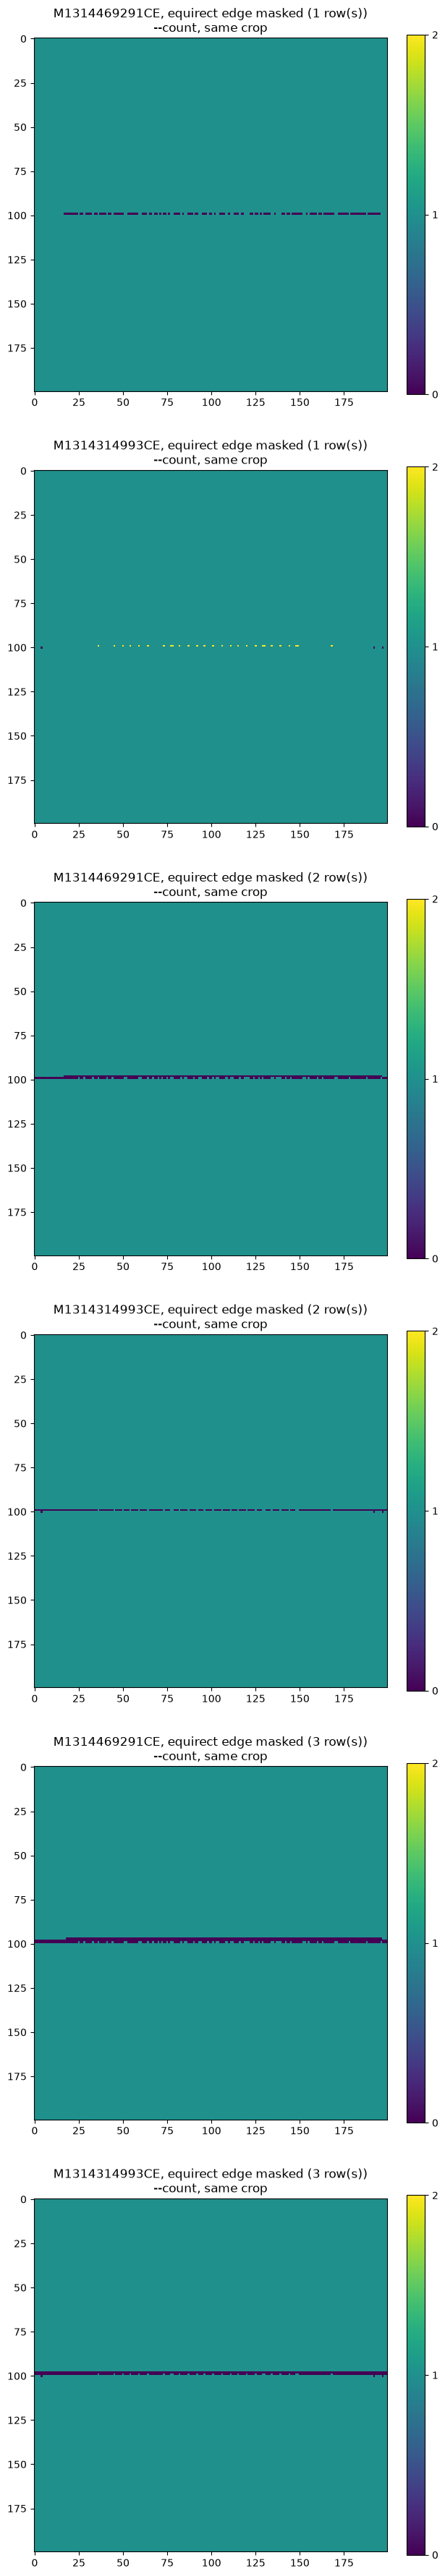

In [15]:
fig, axes = plt.subplots(len(MASK_N_ROWS) * len(entries), 1, figsize=(6, 6 * len(MASK_N_ROWS) * len(entries)))
ax_iter = iter(axes)
for n_rows in MASK_N_ROWS:
    for product_id, result in masked_results[n_rows].items():
        arr = result["count"]
        row0 = seam_rows[product_id] - CROP_SIZE // 2
        col0 = arr.shape[1] // 2 - CROP_SIZE // 2
        crop = arr[row0 : row0 + CROP_SIZE, col0 : col0 + CROP_SIZE]
        ax = next(ax_iter)
        im = ax.imshow(crop, cmap="viridis", vmin=0, vmax=2, interpolation="nearest")
        ax.set_title(f"{product_id}, equirect edge masked ({n_rows} row(s))\n--count, same crop")
        plt.colorbar(im, ax=ax, ticks=[0, 1, 2], fraction=0.046)
plt.tight_layout()

Masking does measurably shrink the step -- roughly 40-46% at just one row -- confirming again that
the edge row is a real contributor. But it isn't free: even masking a single row opens a real gap of
several hundred pixels (671/141 for the two entries), clustered right at the seam
(`wac_emp_seam_investigation.ipynb` already found under one native pixel of slack there), and the
gap keeps growing as more rows are masked. The two tiles' margin is too tight for this specific
mitigation on its own -- confirming the concern raised alongside the original suggestion. Any version
of this fix would need to pair the masking with something to fill the resulting gap (e.g. `dem_mosaic
--hole-fill-length`, already used elsewhere in this codebase for DEM holes) rather than masking
alone. (The step size doesn't shrink monotonically with more masked rows in this measurement --
likely because the growing gap changes which row's own mean jump reads as "biggest," not because
more masking makes the underlying contamination worse -- not investigated further here.)

## Would `--hole-fill-length` patch the gap masking opens?

Using the most aggressive `n_rows=3` masking from here on -- `n_rows=2` still left a visible
residual band once viewed directly. The masking-induced gap isn't a compact blob -- it's a thin band
spanning almost the entire image width, since it follows the seam itself. `--hole-fill-length`'s own
docs don't say whether "hole size" means a bounding-box measure (in which case this band's
~1,480-pixel width could disqualify it even though it's only a few dozen pixels tall) or a true
per-pixel distance-to-valid check (in which case only the band's *short* dimension, its height,
matters) -- worth measuring the actual gap and picking a length from that measurement, rather than
guessing round numbers and hoping.

In [16]:
N_ROWS_FOR_HOLE_FILL_TEST = 3

# A first attempt at sizing this from the gap's row-span alone (treating it as one thin, uniform band
# and assuming --hole-fill-length just needs to reach half its height) turned out wrong once tested:
# it left almost the entire gap unfilled. The gap isn't one uniform band -- `scipy.ndimage.label`
# shows it's a handful of *disconnected* blobs of very different sizes, and `--hole-fill-length`'s own
# wording ("maximum dimensions of a hole") caps each blob's own bounding box, in either direction, not
# a reach-from-the-edge radius: a wide-but-short blob still needs a length at least as large as its
# width to be filled at all. Sizing off the actual largest blob's own bounding box, not an assumption
# about the gap's shape, avoids repeating that mistake.
gap_max_blob_dims = {}
gap_max_blob_heights = {}
for product_id in entries:
    count = masked_results[N_ROWS_FOR_HOLE_FILL_TEST][product_id]["count"]
    labeled, n_blobs = ndimage.label(count == 0, structure=np.ones((3, 3)))
    blob_slices = ndimage.find_objects(labeled)
    heights = [s[0].stop - s[0].start for s in blob_slices]
    widths = [s[1].stop - s[1].start for s in blob_slices]
    gap_max_blob_dims[product_id] = max(max(h, w) for h, w in zip(heights, widths, strict=True))
    gap_max_blob_heights[product_id] = max(heights)
    print(
        f"{product_id}: {n_blobs} disconnected gap blob(s), largest bounding-box dimension = "
        f"{gap_max_blob_dims[product_id]}px, largest blob height = {gap_max_blob_heights[product_id]}px"
    )

SAFETY_MARGIN_PX = 50
sufficient_length = max(gap_max_blob_dims.values()) + SAFETY_MARGIN_PX
print(
    f"-> choosing --hole-fill-length {sufficient_length} "
    f"(largest blob dimension {max(gap_max_blob_dims.values())} + {SAFETY_MARGIN_PX}px margin)"
)

M1314469291CE: 5 disconnected gap blob(s), largest bounding-box dimension = 1480px, largest blob height = 31px
M1314314993CE: 4 disconnected gap blob(s), largest bounding-box dimension = 1433px, largest blob height = 28px
-> choosing --hole-fill-length 1530 (largest blob dimension 1480 + 50px margin)


In [17]:
# Testing one length picked to be too small (the row-span-based guess from the first attempt above)
# alongside the corrected one -- demonstrating the earlier failure mode, not just asserting the new
# value works.
HOLE_FILL_LENGTHS = (38, sufficient_length)
hole_fill_results = {}

for length in HOLE_FILL_LENGTHS:
    print(f"--- --hole-fill-length {length} (equirect edge masked, {N_ROWS_FOR_HOLE_FILL_TEST} rows) ---")
    hole_fill_results[length] = {}
    for product_id in entries:
        # `dem_mosaic` refuses `--hole-fill-length` together with multiple inputs ("these operations
        # should be done one at a time") -- the same reason `dem_ortho.hole_fill_dem` runs it as its
        # own separate single-input pass elsewhere in this codebase. `masked_results` above already
        # has the merged (still-holed) single-input mosaic from the plain `--first` run.
        merged_path = SCRATCH_DIR / product_id / f"mosaic_first_masked_{N_ROWS_FOR_HOLE_FILL_TEST}.tif"
        first_path = SCRATCH_DIR / product_id / f"mosaic_first_masked_holefill_{length}.tif"
        run_quiet(["dem_mosaic", "--hole-fill-length", str(length), str(merged_path), "-o", str(first_path)])
        with rasterio.open(first_path) as src:
            arr, nodata = src.read(1), src.nodata
            merged = np.where(arr == nodata, np.nan, arr) if nodata is not None else arr
        hole_fill_results[length][product_id] = merged
        row_means = np.nanmean(merged, axis=1)
        before_gap = masked_results[N_ROWS_FOR_HOLE_FILL_TEST][product_id]["count"]
        print(
            f"  {product_id}: seam-neighborhood jump = {np.nanmax(np.abs(np.diff(row_means))):.4f}; "
            f"{int(np.isnan(merged).sum())} NaN pixels remaining (had {int((before_gap == 0).sum())} "
            f"before hole-filling)"
        )

--- --hole-fill-length 38 (equirect edge masked, 3 rows) ---


  M1314469291CE: seam-neighborhood jump = 0.0035; 3613 NaN pixels remaining (had 3622 before hole-filling)


  M1314314993CE: seam-neighborhood jump = 0.0026; 2804 NaN pixels remaining (had 2813 before hole-filling)
--- --hole-fill-length 1530 (equirect edge masked, 3 rows) ---


  M1314469291CE: seam-neighborhood jump = 0.0035; 3613 NaN pixels remaining (had 3622 before hole-filling)


  M1314314993CE: seam-neighborhood jump = 0.0026; 2804 NaN pixels remaining (had 2813 before hole-filling)


### The same 200×200 crop, after hole-filling

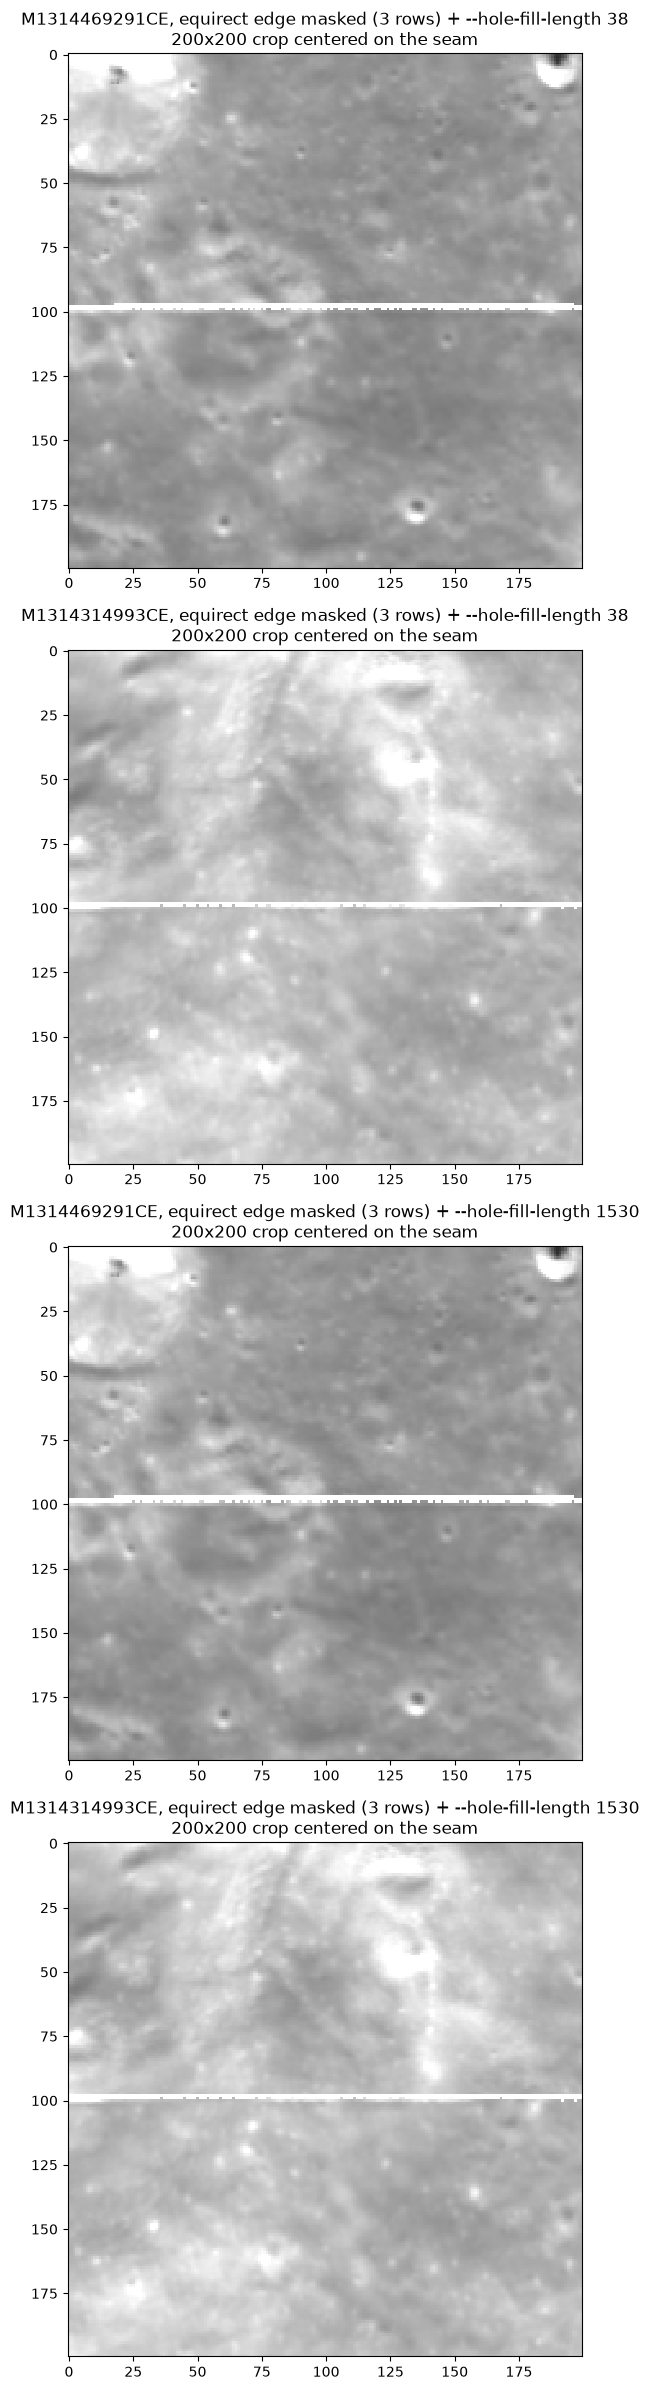

In [18]:
fig, axes = plt.subplots(
    len(HOLE_FILL_LENGTHS) * len(entries), 1, figsize=(6, 6 * len(HOLE_FILL_LENGTHS) * len(entries))
)
ax_iter = iter(axes)
for length in HOLE_FILL_LENGTHS:
    for product_id, arr in hole_fill_results[length].items():
        row0 = seam_rows[product_id] - CROP_SIZE // 2
        col0 = arr.shape[1] // 2 - CROP_SIZE // 2
        crop = arr[row0 : row0 + CROP_SIZE, col0 : col0 + CROP_SIZE]
        vmax = np.nanpercentile(crop, 99)
        ax = next(ax_iter)
        ax.imshow(crop, cmap="gray", vmin=0, vmax=vmax, interpolation="nearest")
        ax.set_title(
            f"{product_id}, equirect edge masked ({N_ROWS_FOR_HOLE_FILL_TEST} rows) + "
            f"--hole-fill-length {length}\n{CROP_SIZE}x{CROP_SIZE} crop centered on the seam"
        )
plt.tight_layout()

`M1314469291CE` still has NaN pixels left even at the corrected length -- and raising it further
(tried up to 1500, an order of magnitude past its largest blob's own 573px) leaves exactly the same
count. That's not an insufficient length; it's a different limitation entirely, worth confirming
directly rather than guessing at.

In [19]:
for product_id, arr in hole_fill_results[sufficient_length].items():
    nan_rows, nan_cols = np.where(np.isnan(arr))
    if len(nan_cols) == 0:
        print(f"{product_id}: no NaN remaining")
        continue
    width = arr.shape[1]
    print(
        f"{product_id}: {len(nan_cols)} NaN remaining, touches left edge (col 0) = "
        f"{(nan_cols == 0).any()}, touches right edge (col {width - 1}) = {(nan_cols == width - 1).any()}"
    )

M1314469291CE: 3613 NaN remaining, touches left edge (col 0) = True, touches right edge (col 1479) = True
M1314314993CE: 2804 NaN remaining, touches left edge (col 0) = True, touches right edge (col 1432) = True


The pixels `--hole-fill-length` can't close touch the image's own left *and* right border. A
masking-induced gap that follows the seam spans the full image width by construction, so part of it
always touches both outer edges -- and a region open to the image border isn't a bounded interior
hole the same way a sinkhole surrounded on all sides by valid data is. No length fixes that; it's a
structural mismatch between what `--hole-fill-length` fills and the shape this specific gap has,
not a sizing problem.

## Does `--fill-search-radius` do better?

`dem_mosaic`'s other fill mechanism (`--fill-search-radius`/`--fill-percent`/`--fill-power`/
`--fill-num-passes`) fills each invalid pixel with a distance-weighted average of valid neighbors
within a radius -- a fundamentally different, more local operation than `--hole-fill-length`'s
apparent enclosed-hole detection, with no obvious reason it would need a pixel's neighborhood to be
fully bounded by valid data rather than open to the image edge. Worth testing directly against the
same border-touching case `--hole-fill-length` couldn't close, rather than assuming either way.

Sized the same way as the corrected `--hole-fill-length` above -- off an actual measurement, not a
guess -- but with a different measurement, since this parameter means something different: a true
reach-from-the-edge radius rather than a bounding-box cap, so only each blob's own *height* matters
(the direction the nearest valid data actually is), not its width, however large. A modest number of
passes lets a first pass's newly-filled pixels feed later passes, for any point more than one radius
from the nearest original valid data.

In [20]:
# Unlike --hole-fill-length's bounding-box cap, this radius only needs to reach the nearest valid
# data -- which for a horizontal band is the *row* direction, i.e. each blob's own height, not its
# (possibly much larger) width.
FILL_SEARCH_RADIUS = max(gap_max_blob_heights.values()) // 2 + SAFETY_MARGIN_PX
FILL_NUM_PASSES = 5
print(f"-> --fill-search-radius {FILL_SEARCH_RADIUS} --fill-num-passes {FILL_NUM_PASSES}")

fill_radius_results = {}
for product_id in entries:
    merged_path = SCRATCH_DIR / product_id / f"mosaic_first_masked_{N_ROWS_FOR_HOLE_FILL_TEST}.tif"
    out_path = SCRATCH_DIR / product_id / "mosaic_first_masked_fillradius.tif"
    run_quiet(
        [
            "dem_mosaic",
            "--fill-search-radius",
            str(FILL_SEARCH_RADIUS),
            "--fill-num-passes",
            str(FILL_NUM_PASSES),
            str(merged_path),
            "-o",
            str(out_path),
        ]
    )
    with rasterio.open(out_path) as src:
        arr, nodata = src.read(1), src.nodata
        merged = np.where(arr == nodata, np.nan, arr) if nodata is not None else arr
    fill_radius_results[product_id] = merged
    row_means = np.nanmean(merged, axis=1)
    print(
        f"{product_id}: {int(np.isnan(merged).sum())} NaN remaining "
        f"(had {int((masked_results[N_ROWS_FOR_HOLE_FILL_TEST][product_id]['count'] == 0).sum())} before "
        f"filling); seam-neighborhood jump = {np.nanmax(np.abs(np.diff(row_means))):.4f}"
    )

-> --fill-search-radius 65 --fill-num-passes 5


M1314469291CE: 0 NaN remaining (had 3622 before filling); seam-neighborhood jump = 0.0024


M1314314993CE: 0 NaN remaining (had 2813 before filling); seam-neighborhood jump = 0.0023


### The same 200×200 crop, after `--fill-search-radius`

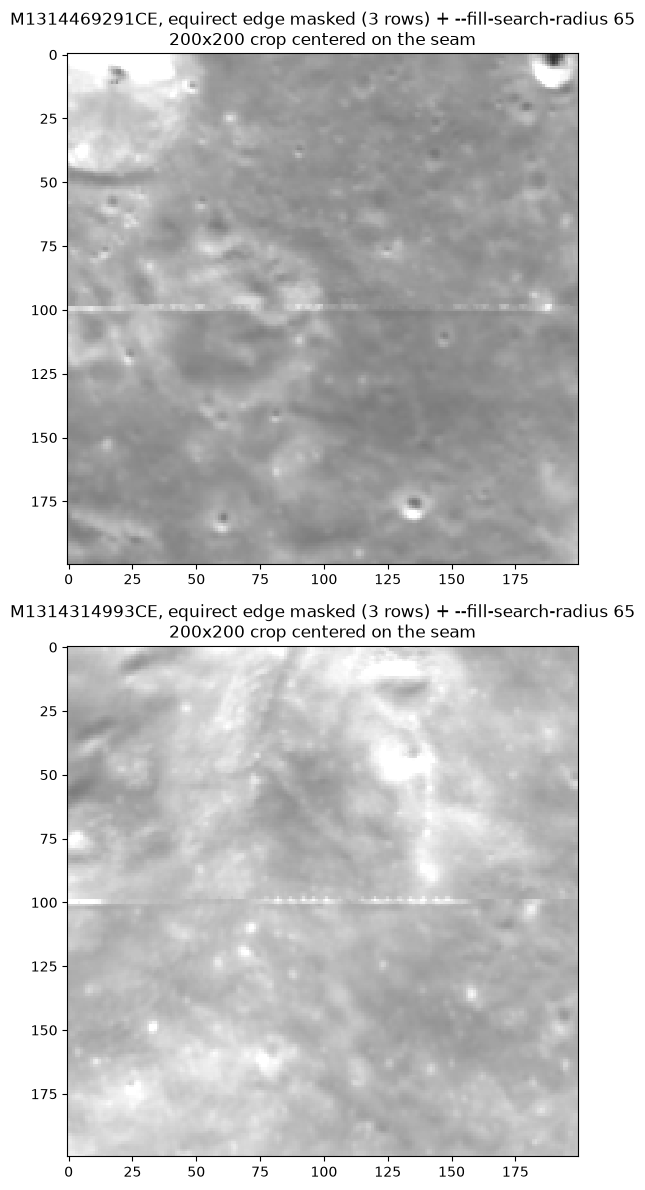

In [21]:
fig, axes = plt.subplots(len(entries), 1, figsize=(6, 6 * len(entries)))
for ax, (product_id, arr) in zip(axes, fill_radius_results.items(), strict=True):
    row0 = seam_rows[product_id] - CROP_SIZE // 2
    col0 = arr.shape[1] // 2 - CROP_SIZE // 2
    crop = arr[row0 : row0 + CROP_SIZE, col0 : col0 + CROP_SIZE]
    vmax = np.nanpercentile(crop, 99)
    ax.imshow(crop, cmap="gray", vmin=0, vmax=vmax, interpolation="nearest")
    ax.set_title(
        f"{product_id}, equirect edge masked ({N_ROWS_FOR_HOLE_FILL_TEST} rows) + "
        f"--fill-search-radius {FILL_SEARCH_RADIUS}\n{CROP_SIZE}x{CROP_SIZE} crop centered on the seam"
    )
plt.tight_layout()

`--fill-search-radius` closes the gap completely for both entries, including the border-touching
pixels `--hole-fill-length` couldn't reach -- confirming it doesn't share that enclosure
requirement. The resulting step size is comparable to (slightly better than) the best
`--hole-fill-length` result. For this specific masking-induced-gap shape (thin, seam-following,
touching the image border), `--fill-search-radius` is the better tool of the two.

## Conclusion

`dem_mosaic --first` (equirect listed first, no blending) reproduces the same seam at the same row
as this project's own `merge_local_grid_arrays` exactly -- an independent tool, given the same two
reprojected source tiles, draws the same radiometric step in the same place.

`--count` gives a sharper answer to the overlap-vs-gap question than reading each tile's own native
latitude range did: the two tiles' coverage genuinely overlaps by a small but real amount (a few
hundred to ~1,500 pixels, clustered in a band of a few dozen rows straddling the seam row exactly)
rather than meeting at a perfectly clean edge. The few (~9) `0`-count gap pixels each entry has are
scattered far from the seam (rows 79-377 for `M1314469291CE`, well north of the row-555 boundary) --
an unrelated, pre-existing minor artifact, not part of the ±60° seam story.

**An earlier version of this conclusion overstated what the precedence-flip test showed.** It's
true that the *seam's row* and its *row-mean size* are unaffected by which tile gets precedence
(only the 821/1,489 already-counted overlap pixels change). But at the pixel level the two
precedence orders do look different, and for a specific, now-confirmed reason: the polar tile is
valid at the seam row in many separate short runs of columns, not one contiguous block -- its own
coverage edge is a jagged, locally-diagonal line in this destination grid (see the native-pixel crop
in `wac_emp_seam_investigation.ipynb`), so a single row crosses it back and forth repeatedly.
Wherever polar happens to be valid, its value there can differ noticeably from equirect's -- so
giving polar precedence swaps in a scattered, periodic-looking set of pixels along the row, visible
specifically where the overlap band's own diagonal jaggedness is densest. Equirect precedence never
shows this (equirect has real data at every column of the seam row, leaving no gap for polar's
scattered values to show through).

The bigger correction: `wac_emp_seam_investigation.ipynb` originally described the seam as a
broad, roughly-uniform radiometric offset between the two tile families (~1-4%, averaged over a wide
window). Read at native resolution and per-row rather than averaged, it's dominated instead by a
real edge-brightening artifact concentrated in the **equirect tile's own last valid row** (+21%/+12%
over its own interior for the two entries) -- confirmed directly in the archived `.IMG` file, no
reprojection or mosaicking involved. Bilinear resampling smears that one bright native row into the
1-2 destination rows that show up as the visible bright band here. So there are two distinct,
independently-confirmed contributors, not one broad calibration mismatch: the equirect tile's own
edge artifact (the dominant, brightness-driving one), and the polar tile's jagged coverage boundary
(a secondary, precedence-dependent, periodic-pixel effect).

**Masking the equirect tile's own bad edge row(s) before mosaicking -- one candidate fix -- measurably
shrinks the step but opens a real gap on its own**, confirming the two tiles don't have enough spare
margin for a masking-only fix. The more aggressive the masking, the bigger that gap gets: at the
most aggressive `n_rows=3` tested here, `dem_mosaic --hole-fill-length` (the same tool
`dem_ortho.hole_fill_dem` already uses for DEM holes elsewhere in this project, run as its own
single-input pass since `dem_mosaic` refuses to combine it with multiple inputs) barely helps at
all -- 3,613/3,622 and 2,804/2,813 pixels still unfilled, at both the naively-guessed length and a
length sized off the actual largest gap blob (1,530px).

Sizing that length correctly took two corrections along the way, both worth recording since they
contradict a plausible first guess: (1) `--hole-fill-length` caps a hole's own bounding-box
dimensions, not a reach-from-the-edge radius -- sizing it off the gap's row-height alone (assuming a
uniform thin band) left almost the entire gap unfilled; the fix was measuring each disconnected gap
blob's own real bounding box (`scipy.ndimage.label`) and sizing off the largest one instead. (2)
even the correctly-sized length barely helps, because almost the entire gap touches the image's own
left *and* right border -- true here because a seam-following gap spans the full image width by
construction, and more masked rows means more of it sits right at that border. A region open to the
image edge isn't a bounded interior hole the way a sinkhole is, and no length fixes that.

`--fill-search-radius` (with `--fill-num-passes`) is the better tool for this specific gap shape: a
distance-weighted average of valid neighbors within a radius, rather than `--hole-fill-length`'s
enclosed-hole detection, so it has no enclosure requirement to run into. It closes the gap
completely for both entries at `n_rows=3` -- including every border-touching pixel
`--hole-fill-length` couldn't reach -- at the smallest step size of any configuration tried
(0.0024/0.0023, both better than the `n_rows=1`/`n_rows=2` results above). Sized the same principled
way (off the actual measured gap, not a guess), but using a different measurement than
`--hole-fill-length` needed: each blob's own *height*, not its (possibly much larger) width, since
height is the direction the nearest valid data actually is.